To create your own package, have a look at the example in `course_tools` and the documentation at https://packaging.python.org/en/latest/tutorials/packaging-projects/.

The key files are
- The `pyproject.toml` file, which specifies that this is a python package
- The `src/bayesian_stats_course_tools/__init__.py`, which makes `bayesian_stats_course_tools` a python module that can be imported.

### Exercise

1. Create a new directory at the top of the JupyterLab file system
2. Create a new Python notebook

3. Obtain an estimate of the value of $\pi$
    - From the definition in `numpy`
    - Using an analytic series expansion: $\pi = 4 \sum_{k=0}^\infty \frac{(-1)^{k}}{2k + 1}$
    - Using a Monte-Carlo estimate: 
        1. Sample $n$ points uniformly on the unit square using `numpy.random.uniform`
        2. Count the number $n_{<r}$ of points with distance $r = \sqrt{x^2+y^2} \leq 1$
        3. Compare the fraction $\frac{n_{<r}}{n}$ to the ratio of the area of a quadrant of a disc to the area of the square to derive an estimate of $\pi$
    - Bonus: Repeat for (hyper) cube and (hyper) ball in 3 or more dimensions. How does the number of samples required to get a robust estimate of $\pi$ change with the number of dimensions? 

4. Use the debugger to step through some iterations of your code.

5. Create plots showing the estimated value as the number of terms in the series expansion and the number of Monte-Carlo samples is varied

In [7]:
import numpy as np
import matplotlib.pyplot as plt


In [19]:
# 1 numpy's definition

num_pi = np.pi

print("NumPy constant: ", num_pi)

# 2 analytic series expansion

summ = 0

for k in range(0,1000000):
    x = (-1)**k
    y = 2*k+1
    z = x/y
    summ += z

analytic_pi = 4*summ

print("analytic series expansion: ", analytic_pi)


# 3 monte-carlo estimation

n_r = 0
n_tot = 0


x_inside, y_inside = [], []
x_outside, y_outside = [], []


for i in range(0,10000):
    n = np.random.uniform(0, 1, 2)
    n_tot += 1
    #print(n)
    
    if np.sqrt(n[0]**2 + n[1]**2) < 1:
        n_r += 1
    #print(n_r)
        x_inside.append(n[0])
        y_inside.append(n[1])
    else:
        x_outside.append(n[0])
        y_outside.append(n[1])

ratio = n_r/n_tot*4

print(f'Monte-Carlo pi estimate: {ratio:.10f}')




NumPy constant:  3.141592653589793


analytic series expansion:  3.1415916535897743
Monte-Carlo pi estimate: 3.1456000000


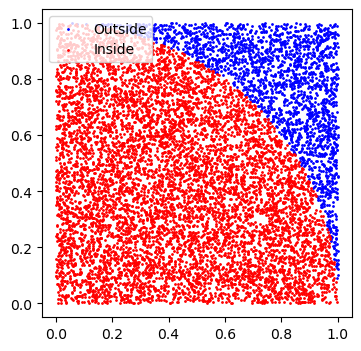

In [20]:
# plot 

plt.figure(figsize=(4, 4))
plt.scatter(x_outside, y_outside, s=1, color="blue", label="Outside")
plt.scatter(x_inside, y_inside, s=1, color="red", label="Inside")
plt.legend()
plt.show()